In [1]:
from sfgen import sfgen
from norm import norm
import numpy as np
from tqdm import trange
import torch
import matplotlib.pyplot as plt

In [2]:
param_path = '../../bat_mod/result/param.xlsx'
model_path = '../trained_model/model1/'

In [3]:
seq_len = 30

In [4]:
data_noise_dict = np.load(model_path + 'data_noise_dict.npy', allow_pickle=True).item()
norm_dict = np.load(model_path + 'norm_dict.npy', allow_pickle=True).item()
model = torch.load(model_path + 'my_model.pth')

In [5]:
start = 0
stop = 380
soc_list = []
soc_real_list = []
soc = data_noise_dict['前一时刻的soc'][start]
for i in trange(start, stop):
    feature = sfgen(soc, param_path, seq_len)
    features = np.concatenate((data_noise_dict['ui数据'][i*30, :, :], feature), axis=-1)
    feature_n = norm(features, norm_dict)
    feature_ts = torch.from_numpy(feature_n).type(torch.float32)
    soc = model(feature_ts.reshape(1, 30, 8)).detach().numpy()
    soc_list.append(soc)
    soc_real_list.append(data_noise_dict['当前soc'][i*30])

100%|███████████████████████████████████████| 380/380 [00:05<00:00, 70.91it/s]


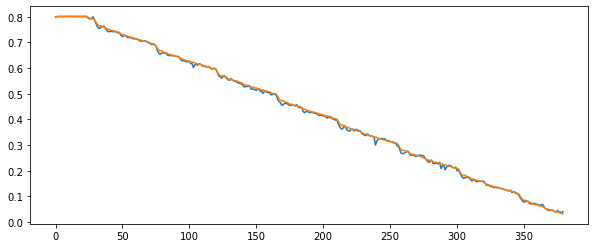

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(soc_list)
plt.plot(soc_real_list)
plt.show()